# EDA — Prototyp AUV v0.2

Analiza eksploracyjna 31 serii czasowych pobranych przez `src/harmonize.py`. Cele:

1. Sprawdzić kompletność danych po alignmentcie.
2. Zobaczyć szeregi w log-skali, znormalizowane do roku bazowego — wizualne wykrycie reżimów.
3. Wstępna kontrola hipotezy: czy istnieją surowce o niskiej korelacji z M2_USA?
4. Wybór kandydatów na $t_0$ na podstawie zmienności w spokojnych okresach.

Notebook nie podejmuje końcowych decyzji — produkuje wykresy i statystyki, na podstawie których ustalimy $t_0$ i ewentualnie ograniczymy zakres surowców do CORE.

In [2]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)

# Pozwala importować src.* z poziomu notebooków
PROTOTYP_ROOT = Path.cwd().parent
if str(PROTOTYP_ROOT) not in sys.path:
    sys.path.insert(0, str(PROTOTYP_ROOT))

from src.config import (
    ALL_SERIES,
    COMMODITY_PRICES,
    CURRENCIES,
    MONEY_SUPPLY,
)

DATA_DIR = PROTOTYP_ROOT / 'data' / 'processed'
FIG_DIR = PROTOTYP_ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9

In [3]:
daily = pd.read_parquet(DATA_DIR / 'daily.parquet')
monthly = pd.read_parquet(DATA_DIR / 'monthly.parquet')

print(f'Daily:   {daily.shape[0]:>5} dni    × {daily.shape[1]} serii')
print(f'Monthly: {monthly.shape[0]:>5} miesięcy × {monthly.shape[1]} serii')
print(f'\nOkres: {daily.index.min().date()} → {daily.index.max().date()}')
print(f'\nSerie ({len(daily.columns)}): {sorted(daily.columns.tolist())}')

Daily:    7828 dni    × 31 serii
Monthly:   360 miesięcy × 31 serii

Okres: 1996-01-01 → 2025-12-31

Serie (31): ['AUD', 'BRL', 'CAD', 'CHF', 'CNY', 'CZK', 'EUR', 'GBP', 'HUF', 'INR', 'JPY', 'KRW', 'M2_BR', 'M2_CN', 'M2_JP', 'M2_USA', 'M3_EU', 'M3_UK', 'MXN', 'PLN', 'SEK', 'SGD', 'ZAR', 'aluminum', 'brent', 'copper', 'corn', 'iron_ore', 'natgas_us', 'wheat', 'wti']


## 1. Kompletność serii

Procent obserwacji niepustych w siatce dziennej. Serie ≥ 95% wchodzą do dalszej analizy bez zastrzeżeń. Serie 80–95% (PLN, EUR) traktujemy ostrożnie — analiza w wielu miejscach będzie ograniczona do okresu, w którym dane istnieją. Serie < 80% lub te, których brakuje (M2 PL, gold, BDI) były omówione w raporcie z `download`.

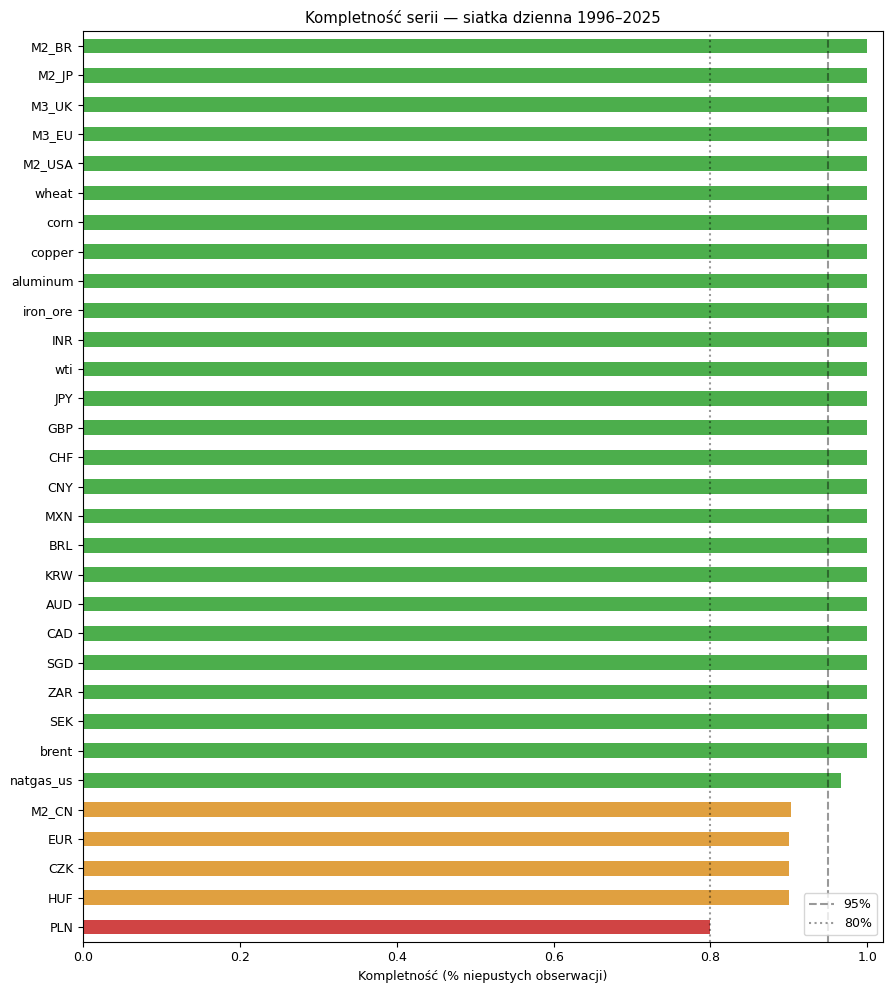


Kompletność (posortowane):
  ✗ PLN                 80.0%
  ~ HUF                 90.0%
  ~ CZK                 90.0%
  ~ EUR                 90.0%
  ~ M2_CN               90.3%
  ✓ natgas_us           96.6%
  ✓ brent              100.0%
  ✓ SEK                100.0%
  ✓ ZAR                100.0%
  ✓ SGD                100.0%
  ✓ CAD                100.0%
  ✓ AUD                100.0%
  ✓ KRW                100.0%
  ✓ BRL                100.0%
  ✓ MXN                100.0%
  ✓ CNY                100.0%
  ✓ CHF                100.0%
  ✓ GBP                100.0%
  ✓ JPY                100.0%
  ✓ wti                100.0%
  ✓ INR                100.0%
  ✓ iron_ore           100.0%
  ✓ aluminum           100.0%
  ✓ copper             100.0%
  ✓ corn               100.0%
  ✓ wheat              100.0%
  ✓ M2_USA             100.0%
  ✓ M3_EU              100.0%
  ✓ M3_UK              100.0%
  ✓ M2_JP              100.0%
  ✓ M2_BR              100.0%


In [4]:
completeness = daily.notna().mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 10))
colors = ['#d04444' if c < 0.8 else '#e0a040' if c < 0.95 else '#4cae4c' for c in completeness]
completeness.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.95, color='black', linestyle='--', alpha=0.4, label='95%')
ax.axvline(0.80, color='black', linestyle=':', alpha=0.4, label='80%')
ax.set_xlabel('Kompletność (% niepustych obserwacji)')
ax.set_title('Kompletność serii — siatka dzienna 1996–2025')
ax.set_xlim(0, 1.02)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_completeness.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKompletność (posortowane):')
for col, pct in completeness.items():
    flag = '✓' if pct >= 0.95 else '~' if pct >= 0.80 else '✗'
    print(f'  {flag} {col:18s} {pct:6.1%}')

## 2. Szeregi w log-skali, znormalizowane do 1996

Każda seria $p_i(t)$ pokazana jako $\log(p_i(t) / p_i(1996))$. To pozwala porównać *tempo wzrostu* różnych aktywów na jednym wykresie, ignorując nominalne poziomy.

Czego oczekujemy / na co patrzymy:

- **Surowce** powinny rosnąć średnio porównywalnie z M2 (bo USD się rozcieńcza), ale z wyraźnymi szokami podażowymi.
- **Waluty** powinny być rozproszone — silne (CHF, JPY) blisko zera, słabe (BRL, ZAR, MXN) wystrzelają wyżej (tracą wartość vs USD).
- **M2/M3** powinny rosnąć monotonnie w górę, w tempie odpowiadającym lokalnej polityce monetarnej.

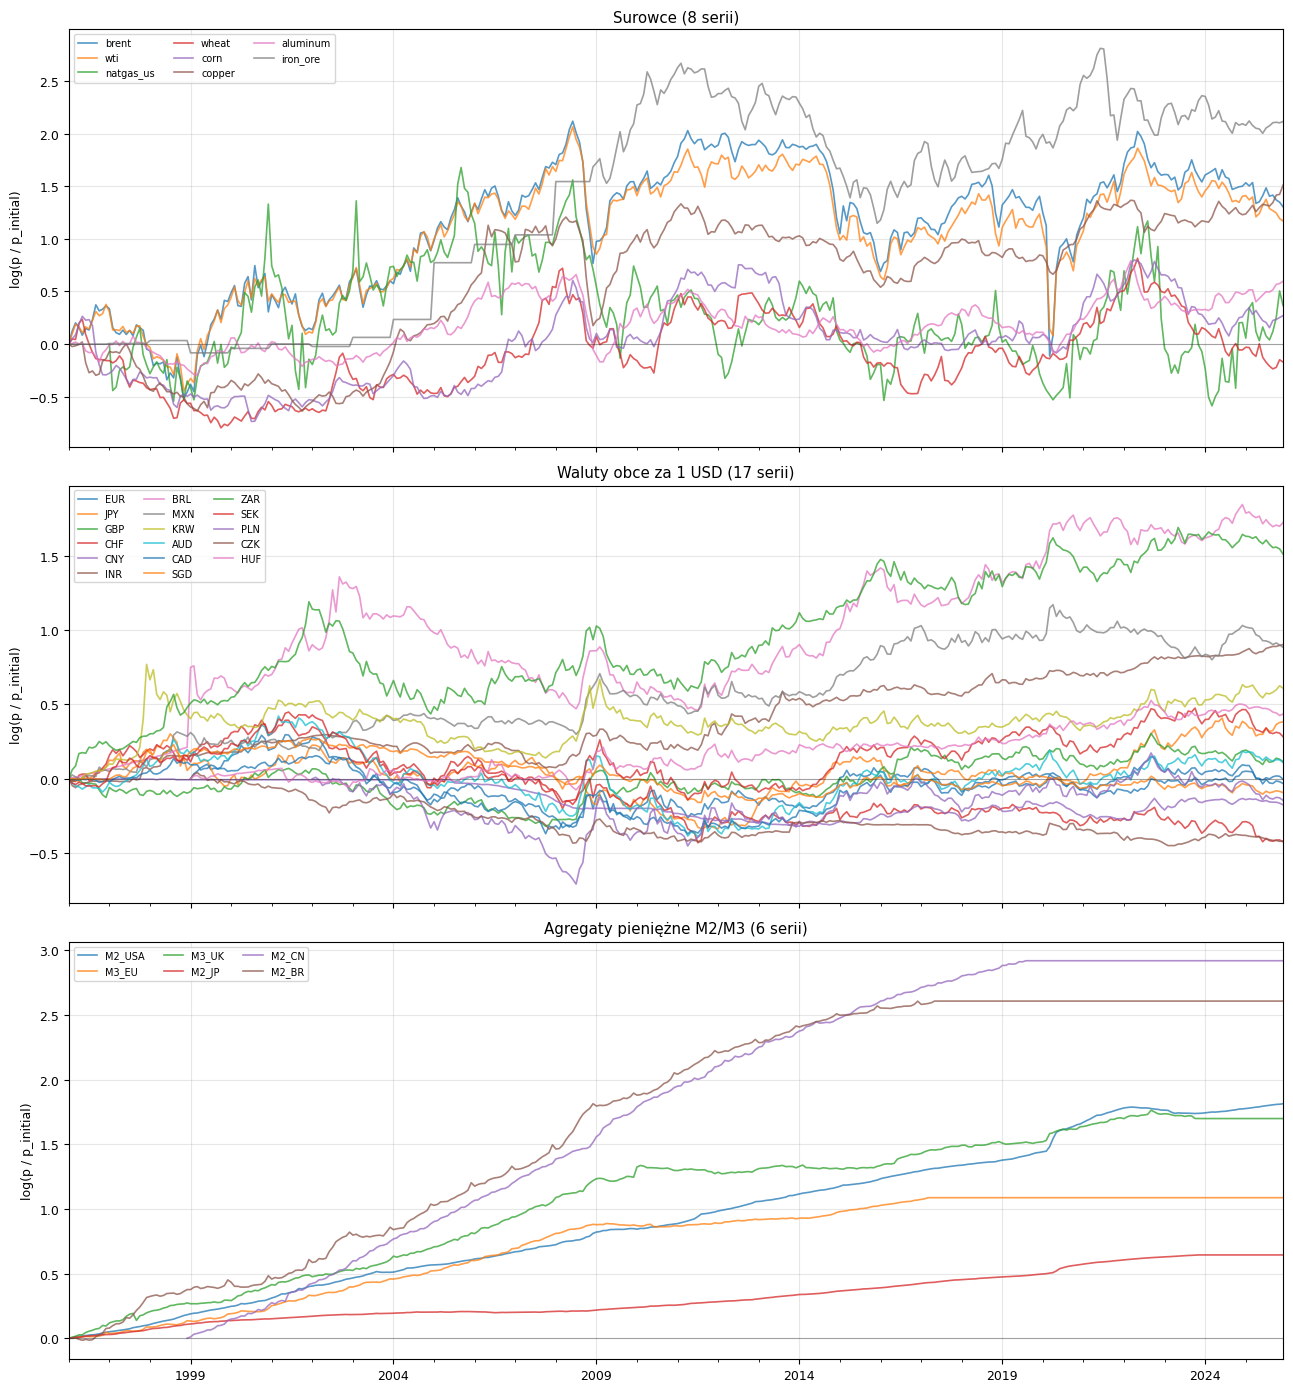

In [5]:
def normalize_log(df_subset: pd.DataFrame) -> pd.DataFrame:
    '''Normalizacja do pierwszej niepustej obserwacji każdej kolumny w skali log.'''
    out = pd.DataFrame(index=df_subset.index)
    for col in df_subset.columns:
        s = df_subset[col].dropna()
        if s.empty or s.iloc[0] <= 0:
            continue
        out[col] = np.log(df_subset[col] / s.iloc[0])
    return out

commodity_cols = [c for c in monthly.columns if c in COMMODITY_PRICES]
currency_cols  = [c for c in monthly.columns if c in CURRENCIES]
money_cols     = [c for c in monthly.columns if c in MONEY_SUPPLY]

fig, axes = plt.subplots(3, 1, figsize=(13, 14), sharex=True)

for ax, cols, title in [
    (axes[0], commodity_cols, f'Surowce ({len(commodity_cols)} serii)'),
    (axes[1], currency_cols, f'Waluty obce za 1 USD ({len(currency_cols)} serii)'),
    (axes[2], money_cols, f'Agregaty pieniężne M2/M3 ({len(money_cols)} serii)'),
]:
    normalized = normalize_log(monthly[cols])
    normalized.plot(ax=ax, alpha=0.75, linewidth=1.2)
    ax.axhline(0, color='black', alpha=0.3, linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel('log(p / p_initial)')
    ax.legend(loc='best', fontsize=7, ncol=3)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_normalized_log.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Surowce vs M2 USA — wizualna kontrola

Hipoteza projektu mówi, że *istnieje kombinacja* surowców mniej skorelowanych z M2 niż pojedyncze surowce. Tutaj patrzymy tylko *wizualnie*, czy w ogóle warto liczyć — czy linie ropy, miedzi, pszenicy są wizualnie różne od linii M2_USA, czy są w lock-step.

Jeśli wszystkie surowce wyglądają jak M2 z hałasem, projekt jest trudniejszy. Jeśli widać dywergencje (np. surowiec stoi w miejscu, gdy M2 rośnie), to znaczy, że w tych surowcach jest "informacja realna" do wyciągnięcia.

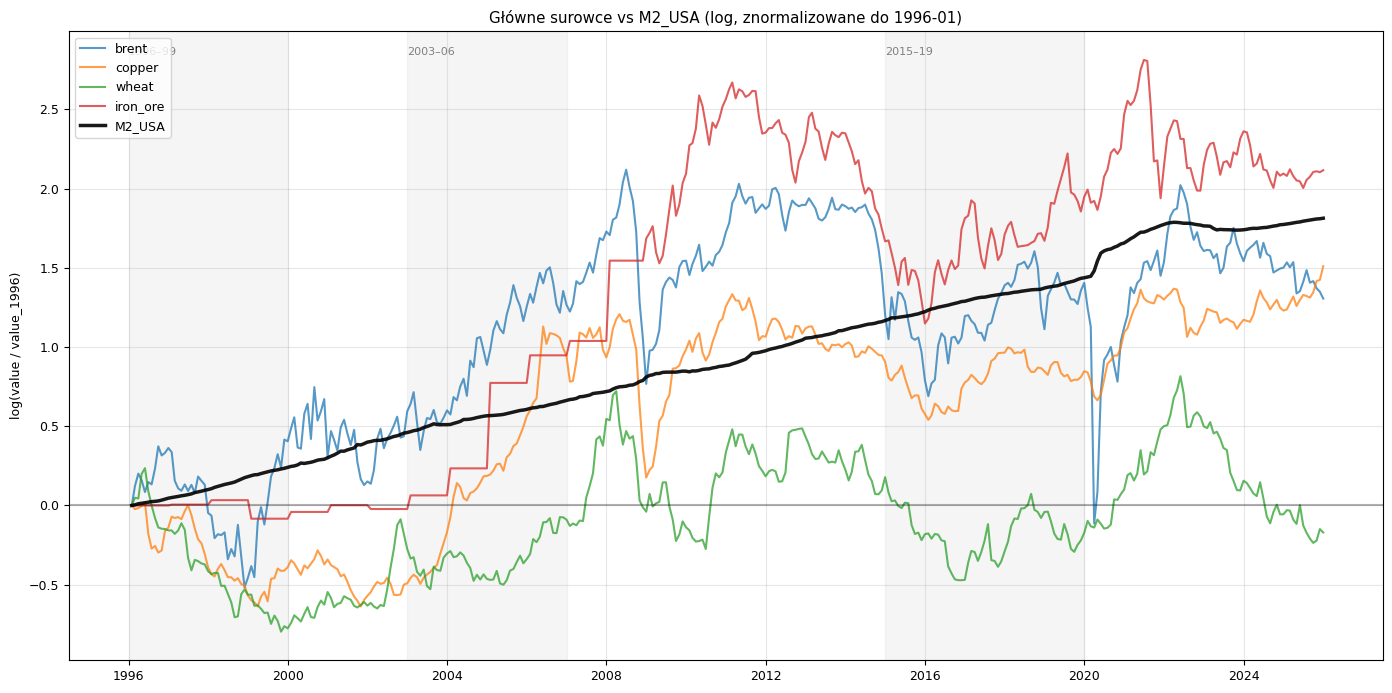

In [6]:
key_commodities = [c for c in ['brent', 'copper', 'wheat', 'iron_ore'] if c in monthly.columns]

fig, ax = plt.subplots(figsize=(14, 7))

for col in key_commodities:
    s = monthly[col].dropna()
    s_norm = np.log(s / s.iloc[0])
    ax.plot(s_norm.index, s_norm.values, label=col, alpha=0.75, linewidth=1.5)

m2 = monthly['M2_USA'].dropna()
m2_norm = np.log(m2 / m2.iloc[0])
ax.plot(m2_norm.index, m2_norm.values, label='M2_USA', color='black', linewidth=2.5, alpha=0.9)

ax.set_title('Główne surowce vs M2_USA (log, znormalizowane do 1996-01)')
ax.set_ylabel('log(value / value_1996)')
ax.axhline(0, color='black', alpha=0.3)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Oznaczenie kandydatów na t_0
for t0_start, t0_end, label in [
    ('1996-01-01', '1999-12-31', '1996–99'),
    ('2003-01-01', '2006-12-31', '2003–06'),
    ('2015-01-01', '2019-12-31', '2015–19'),
]:
    ax.axvspan(pd.Timestamp(t0_start), pd.Timestamp(t0_end), color='gray', alpha=0.08)
    ax.text(pd.Timestamp(t0_start), ax.get_ylim()[1] * 0.95, label, fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(FIG_DIR / '03_commodities_vs_m2.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Macierz korelacji surowiec ↔ M2 (długoterminowa)

Dla każdego surowca liczymy korelację jego log-stóp zwrotu (miesięcznych) z log-stopami zwrotu każdego agregatu monetarnego. To nie jest jeszcze funkcja celu optymalizacji — to *diagnoza, które surowce mają największy / najmniejszy "podpis monetarny"*.

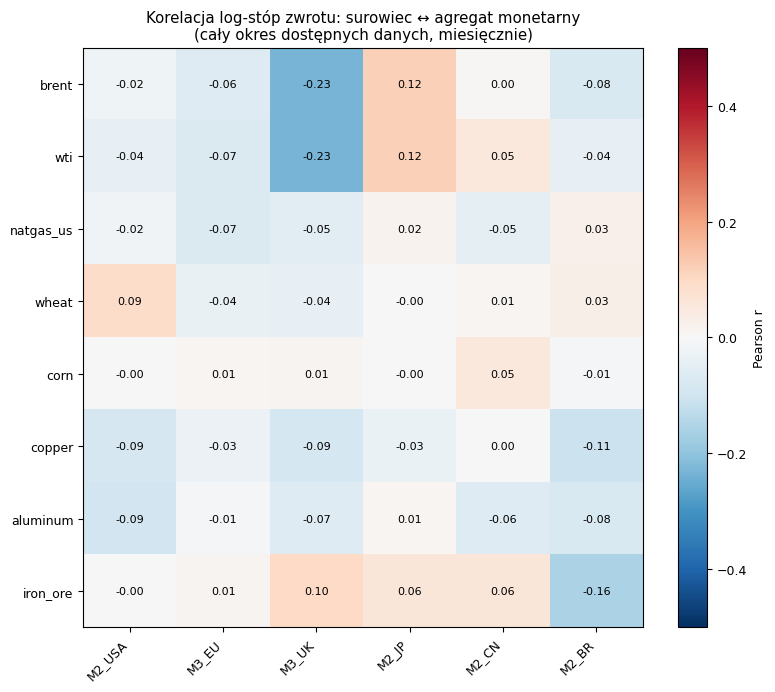


Średnia |korelacja| z M2 dla każdego surowca:
  brent              0.086
  wti                0.094
  natgas_us          0.039
  wheat              0.036
  corn               0.014
  copper             0.057
  aluminum           0.053
  iron_ore           0.066


In [7]:
# Log-stopy zwrotu miesięczne
log_returns = np.log(monthly).diff().dropna(how='all')

commodity_returns = log_returns[commodity_cols].dropna(how='all', axis=1)
money_returns     = log_returns[money_cols].dropna(how='all', axis=1)

# Korelacja każdego surowca z każdym M2/M3
corr_matrix = pd.DataFrame(
    index=commodity_returns.columns,
    columns=money_returns.columns,
    dtype=float,
)
for c in commodity_returns.columns:
    for m in money_returns.columns:
        joined = pd.concat([commodity_returns[c], money_returns[m]], axis=1).dropna()
        if len(joined) > 24:
            corr_matrix.loc[c, m] = joined.corr().iloc[0, 1]

corr_matrix = corr_matrix.astype(float)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title('Korelacja log-stóp zwrotu: surowiec ↔ agregat monetarny\n(cały okres dostępnych danych, miesięcznie)')

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color='black')

plt.colorbar(im, ax=ax, label='Pearson r')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_corr_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nŚrednia |korelacja| z M2 dla każdego surowca:')
for c in corr_matrix.index:
    avg_abs = corr_matrix.loc[c].abs().mean()
    print(f'  {c:18s} {avg_abs:.3f}')

## 5. Wybór kandydatów na $t_0$ — analiza zmienności w trzech oknach

Trzy kandydaci na okres bazowy:

- **1996–1999** — przed bańką dotcom, po stabilizacji post-meksykańskiej.
- **2003–2006** — między dotcomem a GFC, era taniego dolara.
- **2015–2019** — między falą QE a COVID-em, najnowsza spokojna era.

Dla każdego okresu liczymy: średnią zmienność (std log-stóp) surowców i średnią |korelację| surowców z M2_USA. *Niższe wartości = lepszy kandydat na $t_0$*.

Porównanie kandydatów na t_0:

           liczba_obserwacji  sr_zmiennosc  sr_|korelacja|_z_M2
okres                                                          
1996–1999                 35        0.0743               0.1756
2003–2006                 47        0.0906               0.1444
2015–2019                 59        0.0755               0.0847


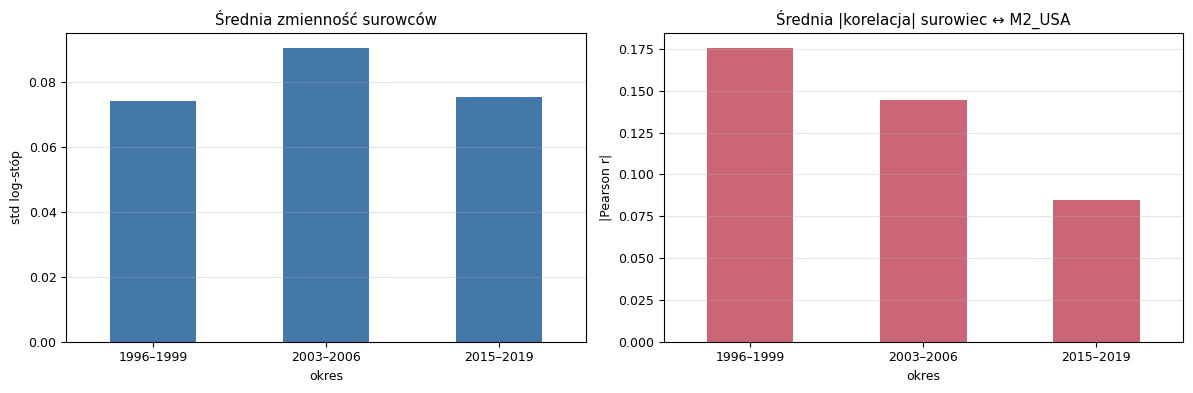

In [8]:
candidate_periods = {
    '1996–1999': ('1996-01-01', '1999-12-31'),
    '2003–2006': ('2003-01-01', '2006-12-31'),
    '2015–2019': ('2015-01-01', '2019-12-31'),
}

rows = []
for name, (start, end) in candidate_periods.items():
    sub = monthly.loc[start:end, commodity_cols + ['M2_USA']]
    sub_returns = np.log(sub).diff().dropna()
    if sub_returns.empty:
        continue
    commodity_returns_period = sub_returns[commodity_cols]
    avg_volatility = commodity_returns_period.std().mean()
    abs_corr = commodity_returns_period.apply(lambda c: c.corr(sub_returns['M2_USA'])).abs().mean()
    rows.append({
        'okres': name,
        'liczba_obserwacji': len(sub_returns),
        'sr_zmiennosc': avg_volatility,
        'sr_|korelacja|_z_M2': abs_corr,
    })

comparison = pd.DataFrame(rows).set_index('okres')
print('Porównanie kandydatów na t_0:\n')
print(comparison.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison['sr_zmiennosc'].plot(kind='bar', ax=axes[0], color='#4477aa')
axes[0].set_title('Średnia zmienność surowców')
axes[0].set_ylabel('std log-stóp')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(alpha=0.3, axis='y')

comparison['sr_|korelacja|_z_M2'].plot(kind='bar', ax=axes[1], color='#cc6677')
axes[1].set_title('Średnia |korelacja| surowiec ↔ M2_USA')
axes[1].set_ylabel('|Pearson r|')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / '05_t0_candidates.png', dpi=150, bbox_inches='tight')
plt.show()

## Wnioski wstępne — do uzupełnienia po obejrzeniu wykresów

*Te pola wypełniamy ręcznie po obejrzeniu czterech zapisanych wykresów (`outputs/figures/01..05_*.png`):*

- **Najstabilniejszy kandydat na $t_0$** (najmniejsza zmienność i |corr| z M2): _____________
- **Surowce o najwyższej korelacji z M2** (potencjalnie do wyłączenia z CORE lub silniejszej regularyzacji): _____________
- **Surowce o najniższej korelacji z M2** (najbardziej obiecujące jako "kotwica realna"): _____________
- **Wizualnie zauważone reżimy / strukturalne załamania**: _____________
- **Czy hipoteza projektu wstępnie wytrzymuje?** TAK / NIE / NIEROZSTRZYGNIĘTE — _____________

Po wypełnieniu tych pól mamy podstawę do przejścia do `02_optimization.ipynb` (właściwa optymalizacja QP + FWL).